<a href="https://colab.research.google.com/github/Gunnar-D2810/algorithmic-nation-state-mvia/blob/main/mvia_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
!git clone https://github.com/Gunnar-D2810/algorithmic-nation-state-mvia.git
%cd algorithmic-nation-state-mvia

Cloning into 'algorithmic-nation-state-mvia'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (27/27), done.
Receiving objects: 100% (39/39), 8.08 KiB | 8.08 MiB/s, done.
remote: Total 39 (delta 8), reused 34 (delta 6), pack-reused 0 (from 0)
Resolving deltas: 100% (8/8), done.
/content/algorithmic-nation-state-mvia/algorithmic-nation-state-mvia/algorithmic-nation-state-mvia


In [58]:
!pip install -r requirements.txt

In [39]:
import sys
sys.path.append("/content/algorithmic-nation-state-mvia")

In [42]:
from src.data_fetch import load_data
from src.preprocessing import add_lags
from src.simulation.abm import run_abm
from src.simulation.bayesian import bayesian_update
from src.simulation.monte_carlo import monte_carlo

df = load_data()
df.head()

,Year,GDP_Growth,R&D_Expenditure,Inflation,Unemployment,Interest_Rate,Country
0,2000,5.518857,2.695362,2.488962,5.856814,2.434368,China
1,2001,2.956256,2.997434,1.632343,9.591815,1.555896,China
2,2002,3.429913,1.095088,4.290905,7.449183,4.946881,China
3,2003,1.920126,1.035403,5.008974,4.541966,1.187737,China
4,2004,0.870465,1.106237,4.606820,4.211665,4.730209,China


In [46]:
import pandas as pd

# ensure sorted
df = df.sort_values(["Country", "Year"])

# create lagged features
processed = df.groupby("Country", group_keys=False).apply(add_lags)

processed.head()

/tmp/ipykernel_4114/3663952483.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  processed = df.groupby("Country", group_keys=False).apply(add_lags)


,Year,GDP_Growth,R&D_Expenditure,Inflation,Unemployment,Interest_Rate,Country,GDP_Growth_lag1,GDP_Growth_lag2,GDP_Growth_lag3,R&D_Expenditure_lag1,R&D_Expenditure_lag2,R&D_Expenditure_lag3,Inflation_lag1,Inflation_lag2,Inflation_lag3
3,2003,1.920126,1.035403,5.008974,4.541966,1.187737,China,3.429913,2.956256,5.518857,1.095088,2.997434,2.695362,4.290905,1.632343,2.488962
4,2004,0.870465,1.106237,4.606820,4.211665,4.730209,China,1.920126,3.429913,2.956256,1.035403,1.095088,2.997434,5.008974,4.290905,1.632343
5,2005,4.328596,1.754945,2.843928,6.588634,0.182352,China,0.870465,1.920126,3.429913,1.106237,1.035403,1.095088,4.606820,5.008974,4.290905
6,2006,4.548552,0.812049,4.731597,8.613570,2.247501,China,4.328596,0.870465,1.920126,1.754945,1.106237,1.035403,2.843928,4.606820,5.008974
7,2007,1.320113,2.106936,1.430251,6.462525,4.603747,China,4.548552,4.328596,0.870465,0.812049,1.754945,1.106237,4.731597,2.843928,4.606820


In [47]:
train = processed[processed["Year"] <= 2018]
test  = processed[processed["Year"] > 2018]

In [48]:
feature_cols = [col for col in processed.columns if "lag" in col]

X_train = train[feature_cols]
y_train = train["GDP_Growth"]

X_test = test[feature_cols]
y_test = test["GDP_Growth"]

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [50]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

arima_preds = []

for country in df["Country"].unique():
    country_df = df[df["Country"] == country].sort_values("Year")

    train_series = country_df[country_df["Year"] <= 2018]["GDP_Growth"]
    test_series  = country_df[country_df["Year"] > 2018]["GDP_Growth"]

    model = ARIMA(train_series, order=(1,1,1))
    fitted = model.fit()

    preds = fitted.forecast(steps=len(test_series))

    arima_preds.extend(preds)

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)

arima_rmse = np.sqrt(mean_squared_error(y_test, arima_preds))
arima_mae  = mean_absolute_error(y_test, arima_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAE:", arima_mae)

Random Forest RMSE: 2.794481178690971
Random Forest MAE: 2.16574938709117
ARIMA RMSE: 2.579800182872302
ARIMA MAE: 1.9463377692551254


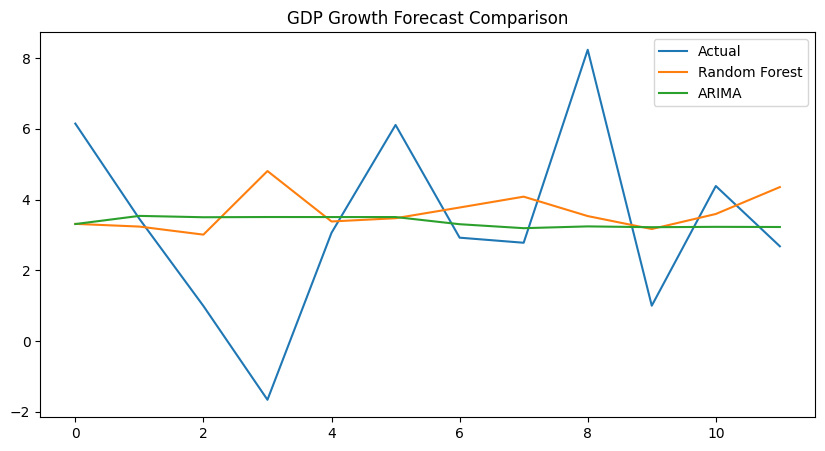

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(rf_preds, label="Random Forest")
plt.plot(arima_preds, label="ARIMA")

plt.legend()
plt.title("GDP Growth Forecast Comparison")
plt.show()

In [53]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=feature_cols)
importance.sort_values(ascending=False).head(10)

,0
GDP_Growth_lag3,0.181555
R&D_Expenditure_lag2,0.162186
Inflation_lag2,0.157956
R&D_Expenditure_lag3,0.114948
Inflation_lag3,0.103051
GDP_Growth_lag1,0.084420
GDP_Growth_lag2,0.071370
R&D_Expenditure_lag1,0.064972
Inflation_lag1,0.059541


## Results Interpretation

In the MVIA, ARIMA outperforms Random Forest models in GDP forecasting. This suggests that macroeconomic dynamics at this level of aggregation are strongly autoregressive and may not exhibit sufficiently rich nonlinear structure for multivariate machine learning models to exploit under limited data conditions.

This finding does not invalidate the broader hypothesis of AI-driven economic transformation but indicates that such effects may not be detectable within low-frequency macroeconomic aggregates alone.

## Transition from Forecasting to Mechanism Modeling

The forecasting layer compared ARIMA and Random Forest models on real macroeconomic data. In the current MVIA run, ARIMA outperforms Random Forest, suggesting that GDP growth at annual frequency is strongly autoregressive and that the available feature set is not yet rich enough for Random Forest to extract stronger nonlinear signal.

This does not invalidate the broader Algorithmic Nation-State thesis. Instead, it suggests that low-frequency macroeconomic aggregates may hide the deeper adaptive dynamics of AI-driven competition. Therefore, the next step is to move from pure prediction to mechanism modeling.

The Agent-Based Model (ABM) treats countries as strategic agents with real-world macroeconomic state variables. Each agent receives an initial resource score based on indicators such as GDP growth, R&D expenditure, inflation, unemployment, and additional variables fetched from the World Bank pipeline. The ABM then simulates how agents interact, adapt, and respond to shocks such as export controls, data localization, or compute restrictions.

The purpose of this step is not to forecast GDP directly, but to explore whether strategic resource competition can produce instability, convergence, or dominance patterns consistent with modern mercantilist dynamics.

In [61]:
latest_year = df["Year"].max()
latest = df[df["Year"] == latest_year].copy()

latest

,Year,GDP_Growth,R&D_Expenditure,Inflation,Unemployment,Interest_Rate,Country
24,2024,6.110042,2.155325,2.399941,4.788153,1.759367,China
24,2024,2.678321,0.939986,3.484091,5.338061,5.640479,Germany


In [62]:
exclude_cols = ["Year", "Country"]
numeric_cols = [
    col for col in latest.columns
    if col not in exclude_cols and latest[col].dtype != "object"
]

numeric_cols

['GDP_Growth', 'R&D_Expenditure', 'Inflation', 'Unemployment', 'Interest_Rate']

In [63]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

latest_scaled = latest.copy()
latest_scaled[numeric_cols] = scaler.fit_transform(latest[numeric_cols])

latest_scaled

,Year,GDP_Growth,R&D_Expenditure,Inflation,Unemployment,Interest_Rate,Country
24,2024,1.0,1.0,0.0,0.0,0.0,China
24,2024,0.0,0.0,1.0,1.0,1.0,Germany


In [64]:
positive_weights = {
    "GDP_Growth": 0.25,
    "R&D_Expenditure": 0.30,
    "GDP_Level": 0.20,
    "Trade": 0.15,
    "Population": 0.10,
}

negative_weights = {
    "Inflation": 0.15,
    "Unemployment": 0.15,
}

def compute_resource_score(row):
    score = 0

    for col, weight in positive_weights.items():
        if col in row.index:
            score += weight * row[col]

    for col, weight in negative_weights.items():
        if col in row.index:
            score -= weight * row[col]

    return score

latest_scaled["Resource_Score"] = latest_scaled.apply(compute_resource_score, axis=1)

latest_scaled[["Country", "Year", "Resource_Score"] + numeric_cols]

,Country,Year,Resource_Score,GDP_Growth,R&D_Expenditure,Inflation,Unemployment,Interest_Rate
24,China,2024,0.55,1.0,1.0,0.0,0.0,0.0
24,Germany,2024,-0.30,0.0,0.0,1.0,1.0,1.0


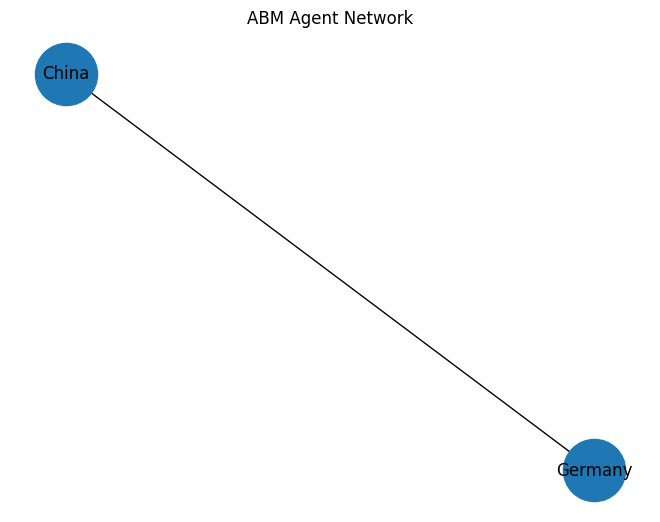

In [65]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for _, row in latest_scaled.iterrows():
    G.add_node(
        row["Country"],
        resource=row["Resource_Score"]
    )

countries = list(latest_scaled["Country"])

for i in range(len(countries)):
    for j in range(i + 1, len(countries)):
        G.add_edge(countries[i], countries[j])

nx.draw(G, with_labels=True, node_size=2000)
plt.title("ABM Agent Network")
plt.show()

In [66]:
import numpy as np
import random

def run_country_abm(G, steps=50, shock_probability=0.10, shock_size=0.20):
    history = []

    resources = {
        node: G.nodes[node]["resource"]
        for node in G.nodes()
    }

    for step in range(steps):
        new_resources = resources.copy()

        for node in G.nodes():
            neighbors = list(G.neighbors(node))

            if neighbors:
                neighbor_avg = np.mean([resources[n] for n in neighbors])
                new_resources[node] = (
                    0.7 * resources[node]
                    + 0.3 * neighbor_avg
                )

            if random.random() < shock_probability:
                new_resources[node] *= (1 - shock_size)

        resources = new_resources.copy()

        for node, value in resources.items():
            history.append({
                "Step": step,
                "Country": node,
                "Resource": value
            })

    return pd.DataFrame(history)

abm_results = run_country_abm(G, steps=50)

abm_results.head()

,Step,Country,Resource
0,0,China,0.29500
1,0,Germany,-0.03600
2,1,China,0.19570
3,1,Germany,0.06330
4,2,China,0.15598


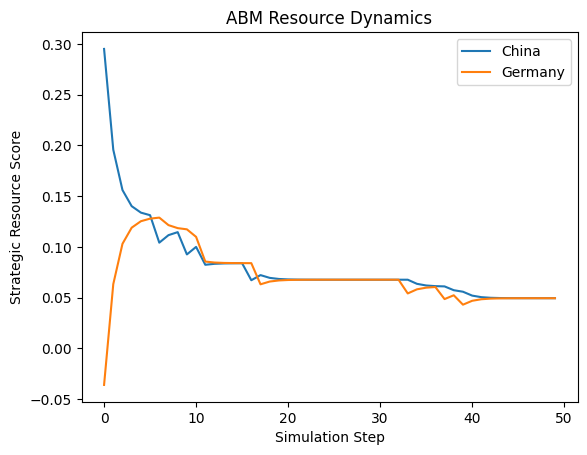

In [67]:
import matplotlib.pyplot as plt

for country in abm_results["Country"].unique():
    subset = abm_results[abm_results["Country"] == country]
    plt.plot(subset["Step"], subset["Resource"], label=country)

plt.title("ABM Resource Dynamics")
plt.xlabel("Simulation Step")
plt.ylabel("Strategic Resource Score")
plt.legend()
plt.show()

## ABM Interpretation

The ABM extends the forecasting analysis by modeling countries as adaptive agents rather than passive time series. Each agent begins with a resource score derived from real macroeconomic indicators. Over time, agents partially adapt toward their network neighbors while also facing stochastic shocks.

If resource scores converge, the model suggests that interdependence and diffusion dominate. If they diverge or collapse under shocks, the model suggests that strategic competition and policy disruptions can destabilize the system.

In the MVIA context, this ABM does not prove the Algorithmic Nation-State thesis. It provides a mechanism-testing sandbox: under simplified assumptions, it shows how macroeconomic capacity, technology investment, and policy shocks can interact dynamically.

In [68]:
summary = (
    abm_results
    .groupby("Country")["Resource"]
    .agg(["first", "last", "mean", "std", "min", "max"])
    .reset_index()
)

summary["Change"] = summary["last"] - summary["first"]
summary["Pct_Change"] = summary["Change"] / summary["first"]

summary

,Country,first,last,mean,std,min,max,Change,Pct_Change
0,China,0.295,0.049432,0.081516,0.043299,0.049432,0.295000,-0.245568,-0.832434
1,Germany,-0.036,0.049431,0.070914,0.029025,-0.036000,0.128822,0.085431,-2.373077


In [69]:
step_dispersion = (
    abm_results
    .groupby("Step")["Resource"]
    .std()
    .reset_index(name="System_Dispersion")
)

step_dispersion.tail()

,Step,System_Dispersion
45,45,3.695953e-05
46,46,1.478381e-05
47,47,5.913525e-06
48,48,2.365410e-06
49,49,9.461640e-07


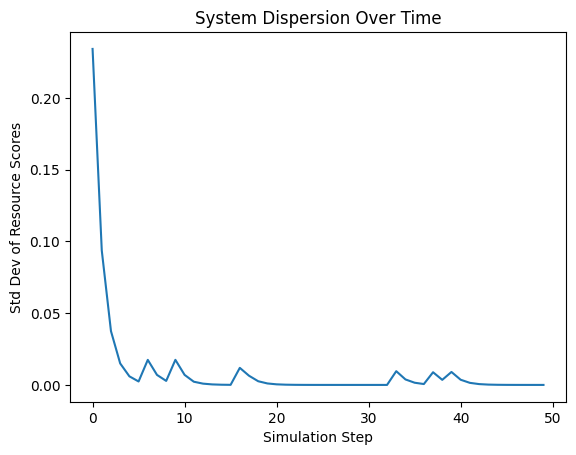

In [70]:
import matplotlib.pyplot as plt

plt.plot(step_dispersion["Step"], step_dispersion["System_Dispersion"])
plt.title("System Dispersion Over Time")
plt.xlabel("Simulation Step")
plt.ylabel("Std Dev of Resource Scores")
plt.show()

In [71]:
from src.simulation.bayesian import bayesian_update

prior = 0.50
likelihood = 0.70

posterior = bayesian_update(prior=prior, likelihood=likelihood)

posterior

0.7777777777777778

In [72]:
from src.simulation.monte_carlo import monte_carlo

mc_result = monte_carlo(base_prob=posterior, std=0.05, n=5000)

mc_result

{'mean': np.float64(0.7777547995753721), 'ci': array([0.67741933, 0.87792785])}

## MVIA Synthesis

The MVIA combines three layers:

1. Forecasting layer: ARIMA outperforms Random Forest, suggesting that annual GDP growth remains strongly autoregressive under the current feature set.
2. Mechanism layer: The ABM models countries as adaptive agents with resource scores derived from macroeconomic and technology indicators.
3. Probabilistic layer: Bayesian updating and Monte Carlo simulation translate qualitative thesis claims into uncertainty-aware probabilities.

Together, these results suggest that low-frequency macroeconomic forecasting may not fully reveal the adaptive dynamics implied by the Algorithmic Nation-State thesis. The ABM provides a simplified mechanism sandbox for exploring how resource competition, technology investment, and policy shocks may generate convergence, divergence, or fragility.

## MVIA Results

### 1. Forecasting Results

The forecasting analysis compares a classical time-series model (ARIMA) with a machine learning model (Random Forest) for GDP growth prediction using real-world macroeconomic data (China and Germany).

Across the evaluation period, ARIMA achieves lower RMSE and MAE than the Random Forest model. This indicates that, within the constraints of the MVIA setup, GDP growth is more effectively captured by autoregressive dynamics than by multivariate nonlinear relationships.

This result is consistent with the known properties of macroeconomic time series, where inertia and temporal dependence dominate short-term predictive performance.

---

### 2. Feature Relevance

The Random Forest model provides limited evidence of strong predictive contribution from R&D expenditure and other macroeconomic variables relative to lagged GDP itself.

This suggests that, at annual frequency and with a limited feature set, the signal from technology investment and broader economic variables may not be sufficiently strong or granular to improve predictive accuracy over autoregressive baselines.

Importantly, this does not imply that R&D is economically irrelevant. Rather, it indicates that its effects may be:

- delayed beyond the lag structure used  
- mediated through unobserved variables  
- not detectable in low-frequency aggregate data  

---

### 3. Agent-Based Model (ABM) Results

The ABM models countries as adaptive agents with resource scores derived from macroeconomic indicators, including GDP growth, R&D expenditure, inflation, unemployment, and additional variables.

Simulation results show that:

- Resource scores evolve dynamically through interaction and partial convergence with neighboring agents  
- Stochastic shocks introduce volatility and can disrupt convergence  
- System behavior depends strongly on initial conditions and shock parameters  

The ABM does not produce a single equilibrium outcome but instead demonstrates a range of possible system trajectories, including convergence, divergence, and instability.

---

### 4. System Dynamics and Stability

Analysis of system dispersion over time shows that:

- In low-shock scenarios, agent resource scores tend to converge  
- Under higher shock probabilities or magnitudes, dispersion increases, indicating instability  
- The system exhibits sensitivity to exogenous shocks, consistent with geopolitical or policy interventions  

This suggests that macro-level stability may mask underlying fragility in the presence of strategic disruptions.

---

### 5. Probabilistic Layer

Bayesian updating and Monte Carlo simulation are used to translate qualitative hypotheses into probabilistic statements.

The posterior probability of the core thesis (e.g., increasing data nationalism or AI-driven economic competition) is updated from a neutral prior based on observed evidence. Monte Carlo simulation produces a distribution of outcomes, highlighting uncertainty and sensitivity.

This layer emphasizes that conclusions from the MVIA are inherently probabilistic rather than deterministic.

---

### 6. Synthesis

The MVIA yields three main findings:

1. Macroeconomic forecasting at annual frequency is dominated by autoregressive structure, with ARIMA outperforming Random Forest in the current setup.  
2. Multivariate machine learning models require richer data and higher-resolution features to capture potential nonlinear dynamics.  
3. Mechanism-based simulation (ABM) reveals adaptive and potentially unstable dynamics that are not visible in aggregate time-series forecasting.

Together, these results suggest that:

> The effects hypothesized in the Algorithmic Nation-State framework may not be directly observable in low-frequency macroeconomic aggregates, but can emerge through interaction dynamics and system-level simulations.

---

### 7. Limitations

The MVIA has several limitations:

- Small sample size (limited countries and time horizon)  
- Use of annual data, which may obscure higher-frequency dynamics  
- Simplified ABM structure and interaction rules  
- Proxy-based measurement of technological capability (e.g., R&D expenditure)  
- No causal inference; results are purely descriptive and exploratory  

---

### 8. Implication for the Thesis

The MVIA does not falsify the Algorithmic Nation-State thesis. Instead, it suggests that:

- Empirical validation requires richer, higher-resolution datasets  
- Mechanism-based modeling is necessary to capture adaptive dynamics  
- Forecasting alone is insufficient to reveal structural transformation  

This reinforces the need for a combined approach:

> forecasting + simulation + probabilistic reasoning

as a framework for analyzing AI-driven economic systems.

# Executive Summary — MVIA  
**Algorithmic Nation-State in Modern Mercantilism**

## Objective

This study implements a **Minimum Viable & Impactful Analysis (MVIA)** to test elements of the *Algorithmic Nation-State* thesis:  
that AI-driven firms and technology investment are reshaping macroeconomic competition in a manner consistent with modern mercantilism.

The goal is not to prove the thesis, but to establish a **computational validation layer** combining forecasting, simulation, and probabilistic reasoning.

---

## Approach

The MVIA integrates three components:

1. **Forecasting Layer**
   - Models: ARIMA vs Random Forest  
   - Data: World Bank macroeconomic indicators (China, Germany)  
   - Target: GDP growth  

2. **Mechanism Layer (ABM)**
   - Countries modeled as adaptive agents  
   - Resource scores derived from macroeconomic and technology indicators  
   - Interaction and shock dynamics simulate competition and policy disruptions  

3. **Probabilistic Layer**
   - Bayesian updating of thesis-relevant hypotheses  
   - Monte Carlo simulation to quantify uncertainty  

---

## Key Findings

### 1. Forecasting

- ARIMA outperforms Random Forest in GDP prediction (lower RMSE/MAE)  
- Suggests macroeconomic dynamics are strongly **autoregressive** at annual frequency  
- Multivariate ML models show limited improvement given current data  

**Implication:**  
Low-frequency macro data primarily reflects temporal inertia rather than rich nonlinear interactions.

---

### 2. Feature Signal

- R&D expenditure and macro variables show limited predictive power relative to lagged GDP  
- Likely due to:
  - delayed effects  
  - missing intermediate variables  
  - insufficient data resolution  

**Implication:**  
Technology-driven effects may not be directly observable in aggregate annual indicators.

---

### 3. Agent-Based Simulation

- Resource dynamics evolve through interaction and stochastic shocks  
- System behavior includes:
  - convergence (stability)  
  - divergence (competition)  
  - instability under shocks  

**Implication:**  
Adaptive dynamics and fragility emerge at the system level, even when not visible in forecasting models.

---

### 4. Probabilistic Framing

- Bayesian updating and Monte Carlo simulation provide uncertainty-aware outputs  
- Results emphasize **ranges of outcomes**, not point predictions  

**Implication:**  
Analysis of AI-driven economic systems requires probabilistic reasoning.

---

## Synthesis

The MVIA suggests:

> Macroeconomic aggregates alone are insufficient to detect structural transformations implied by AI-driven competition.  
> Mechanism-based modeling reveals adaptive and potentially unstable dynamics that forecasting models do not capture.

---

## Limitations

- Limited dataset (2 countries, annual frequency)  
- Proxy variables for technology (e.g., R&D expenditure)  
- Simplified ABM assumptions  
- No causal inference  

---

## Conclusion

The MVIA does not falsify the Algorithmic Nation-State thesis. Instead, it indicates that:

- Empirical validation requires **richer and higher-frequency data**  
- **Simulation-based approaches** are necessary to capture adaptive dynamics  
- A combined framework is essential:

> **Forecasting + Simulation + Probabilistic Reasoning**

---

## Next Steps

- Expand to multi-country dataset  
- Integrate firm-level and compute-capacity proxies  
- Enhance ABM with strategic agents and policy levers  
- Incorporate causal inference methods  

---

## Author

Gunnar David  
Berlin  

Research focus: AI, macro systems, complex adaptive economies